   StockCode       Week  TotalQuantity  TotalRevenue  NumOrders  NumCustomers  \
0      23843 2010-11-29              0           0.0          0             0   
1      23843 2010-12-06              0           0.0          0             0   
2      23843 2010-12-13              0           0.0          0             0   
3      23843 2010-12-20              0           0.0          0             0   
4      23843 2010-12-27              0           0.0          0             0   
5      23843 2011-01-03              0           0.0          0             0   
6      23843 2011-01-10              0           0.0          0             0   
7      23843 2011-01-17              0           0.0          0             0   
8      23843 2011-01-24              0           0.0          0             0   
9      23843 2011-01-31              0           0.0          0             0   
10     23843 2011-02-07              0           0.0          0             0   
11     23843 2011-02-14     

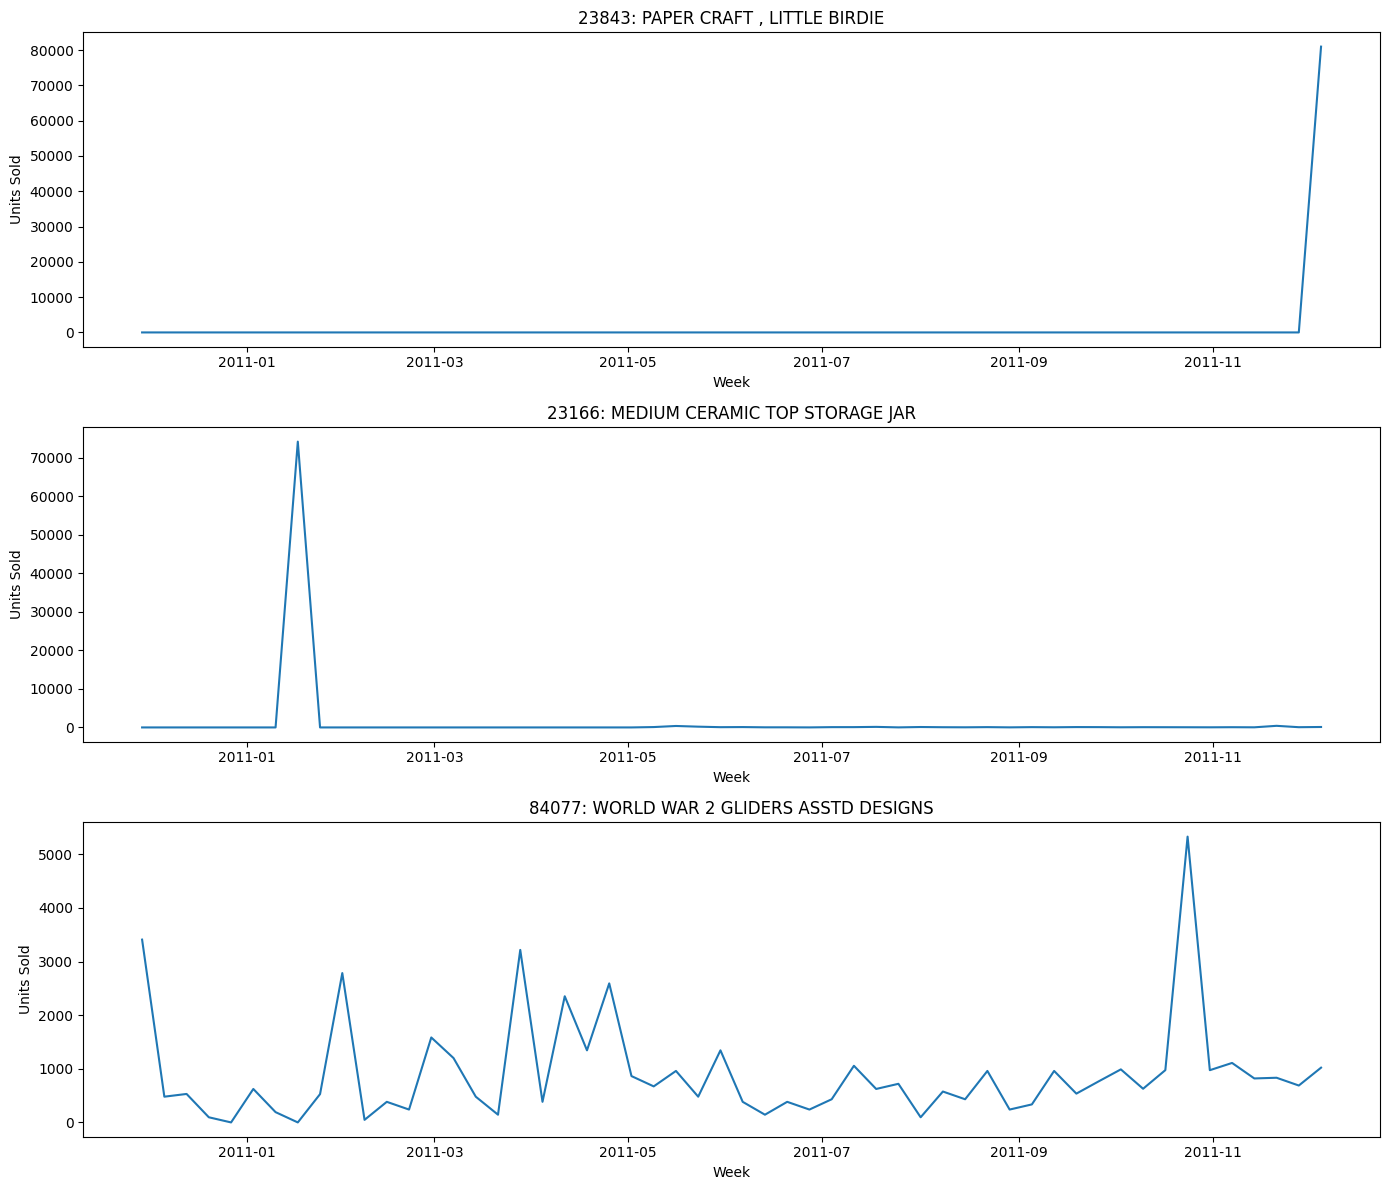

✅ Demand time series plotted


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

demand = pd.read_csv('../data/processed/weekly_demand.csv')
demand['Week'] = pd.to_datetime(demand['Week'])

print(demand.head(20))
print(f"\nProducts: {demand['StockCode'].nunique()}")
print(f"Weeks: {demand['Week'].nunique()}")

# Plot demand for top 3 products
top_3 = demand.groupby('StockCode')['TotalQuantity'].sum().nlargest(3).index

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, product in zip(axes, top_3):
    product_data = demand[demand['StockCode'] == product]
    description = product_data['Description'].iloc[0]
    ax.plot(product_data['Week'], product_data['TotalQuantity'])
    ax.set_title(f"{product}: {description[:40]}")
    ax.set_xlabel('Week')
    ax.set_ylabel('Units Sold')

plt.tight_layout()
plt.savefig('demand_time_series.png')
plt.show()
print("✅ Demand time series plotted")

### Observations
- Products 23843 and 23166 show flat-then-single-spike patterns, likely driven by one-off bulk/wholesale orders rather than organic demand — poor candidates for time series forecasting despite ranking high by total volume.

- Product 84077 shows genuine week-to-week variability with recurring peaks — a much better forecasting candidate.

In [3]:
# Analyze product consistency — how many weeks each product actually sold in
consistency = (
    demand.groupby('StockCode')
    .agg(
        TotalQuantity=('TotalQuantity', 'sum'),
        ActiveWeeks=('TotalQuantity', lambda x: (x > 0).sum()),
        TotalWeeks=('TotalQuantity', 'count'),
        AvgWeeklyQty=('TotalQuantity', 'mean'),
        StdWeeklyQty=('TotalQuantity', 'std'),
    )
    .reset_index()
)

consistency['PctWeeksActive'] = consistency['ActiveWeeks'] / consistency['TotalWeeks'] * 100
consistency['CoeffOfVariation'] = consistency['StdWeeklyQty'] / consistency['AvgWeeklyQty']

# Merge back product descriptions
descriptions = demand[['StockCode', 'Description']].drop_duplicates()
consistency = consistency.merge(descriptions, on='StockCode')

# Sort by consistency (active weeks first, then lower variability)
consistency_sorted = consistency.sort_values(
    by=['PctWeeksActive', 'CoeffOfVariation'], 
    ascending=[False, True]
)

print(consistency_sorted[['StockCode', 'Description', 'TotalQuantity', 
                            'PctWeeksActive', 'CoeffOfVariation']].to_string(index=False))

StockCode                        Description  TotalQuantity  PctWeeksActive  CoeffOfVariation
   85099B            JUMBO BAG RED RETROSPOT          41981       98.148148          0.610610
    84946       ANTIQUE SILVER T-LIGHT GLASS          16257       98.148148          0.613082
    22178    VICTORIAN GLASS HANGING T-LIGHT          21905       98.148148          0.671765
    21212    PACK OF 72 RETROSPOT CAKE CASES          22465       98.148148          0.717820
   85123A WHITE HANGING HEART T-LIGHT HOLDER          34705       98.148148          0.858493
    84879      ASSORTED COLOUR BIRD ORNAMENT          32727       98.148148          0.889639
    22616         PACK OF 12 LONDON TISSUES           24337       98.148148          1.023049
    22197                     POPCORN HOLDER          45632       98.148148          1.094811
    21977 PACK OF 60 PINK PAISLEY CAKE CASES          19993       98.148148          1.210707
    21915             RED  HARMONICA IN BOX           16925 

### Improved Product Selection Method
Selecting products by raw total volume is misleading — it surfaces products dominated by single bulk/wholesale orders (e.g., StockCode 23843 sold 80,995 units, but 98% of that came from a single week — PctWeeksActive = 1.85%).

**Better approach**: rank products by:
1. `PctWeeksActive` (% of weeks with any sales) — descending
2. `CoeffOfVariation` (std/mean of weekly quantity) — ascending

This surfaces products like 85099B, 84946, 22178, and 21212, which sell in ~98% of weeks with much lower relative variability (CoeffOfVariation 0.6–0.9) — genuinely forecastable demand patterns, unlike the volume-ranked top 5.

**Action for Week 4**: use this consistency-based ranking (not raw volume) to select the top N products for Prophet forecasting.